In [13]:
import rebound
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy import signal
import heyoka as hy
from celmech import Poincare, PoincareHamiltonian
import symengine as se
import time
import sympy as sp

In [14]:
#constants and helper functions
m_sat = 2.85837e-4
m_jup = 9.945786e-4
m_c = 1

def ft(times, x):
    fs = 1/((times[1] - times[0])/(2*np.pi))
    f, pxx = signal.periodogram(x,fs=fs,window='hann',scaling='density')
    return f,pxx

def pomega_ft(times,pomega,ecc):
    k = ecc*np.cos(pomega)
    h = ecc*np.sin(pomega)*1j
    z = h + k
    f,pxx = ft(times, z)
    return f,pxx

#from celmech docs
def get_pomega(kap,eta):
    return np.arctan2(-eta,kap)

def get_ecc(kap,eta,L):
    P = (kap**2 + eta**2)/2
    return np.sqrt(1 - (1 - P/L)**2)

In [15]:

def hk_integrate(pham,sim_time,num_data_points):
    #H_num = pham.H.subs(dict(pham.H_params))
    H_se = se.sympify(pham.H)
    clean_params_se = {se.sympify(k): v for k, v in dict(pham.H_params).items()
                   if not (hasattr(v, '__float__') and np.isnan(float(v)))}
    H_num = H_se.subs(clean_params_se)
    nan_symbols = {s: 0 for s in H_num.free_symbols 
               if str(s) not in {'Lambda1', 'Lambda2', 'eta1', 'eta2', 
                                  'kappa1', 'kappa2', 'lambda1', 'lambda2',
                                  'rho1', 'rho2', 'sigma1', 'sigma2'}}
    H_num = H_num.subs(nan_symbols)

    
    rho1,rho2,sigma1,sigma2 = se.symbols('rho1 rho2 sigma1 sigma2')
    sym_map = {s: 0 for s in H_num.free_symbols if str(s) in ('rho1', 'rho2', 'sigma1', 'sigma2')}
    H_planar = H_num.subs(sym_map)
    #H_planar = H_num.subs({rho1: 0, rho2: 0, sigma1: 0, sigma2: 0})
    H_planar = se.sympify(H_planar)
    print(sorted(str(s) for s in H_planar.free_symbols))

    lam1,lam2 = se.symbols('lambda1 lambda2')
    Lam1,Lam2 = se.symbols('Lambda1 Lambda2')
    eta1,eta2 = se.symbols('eta1 eta2')
    kap1, kap2 = se.symbols('kappa1 kappa2')

    print('*** Differentiating  ***')

    sym_dict = {str(s): s for s in H_planar.free_symbols}
    lam1 = sym_dict['lambda1']
    lam2 = sym_dict['lambda2']
    Lam1 = sym_dict['Lambda1']
    Lam2 = sym_dict['Lambda2']
    eta1 = sym_dict['eta1']
    eta2 = sym_dict['eta2']
    kap1 = sym_dict['kappa1']
    kap2 = sym_dict['kappa2']

    dLam1_dt = -se.diff(H_planar, lam1)
    dLam2_dt = -se.diff(H_planar, lam2)
    dlam1_dt =  se.diff(H_planar, Lam1)
    dlam2_dt =  se.diff(H_planar, Lam2)

    deta1_dt  = se.diff(H_planar, kap1)
    dkap1_dt  =  -se.diff(H_planar, eta1)
    deta2_dt  = se.diff(H_planar, kap2)
    dkap2_dt  =  -se.diff(H_planar, eta2)

    derivs = [dlam1_dt, dLam1_dt, dlam2_dt, dLam2_dt, deta1_dt, dkap1_dt, deta2_dt, dkap2_dt]

    vars_list = [lam1, Lam1, lam2, Lam2, eta1, kap1, eta2, kap2]
    func = se.Lambdify(vars_list,H_planar)

    jup = pham.state.particles[1]
    sat = pham.state.particles[2]

    initial_conditions = [jup.l, jup.Lambda, sat.l, sat.Lambda,jup.eta, jup.kappa, sat.eta, sat.kappa]
    derivs_at_0 = func(*initial_conditions)

    lam1_hy, Lam1_hy, lam2_hy, Lam2_hy, eta1_hy, kap1_hy, eta2_hy, kap2_hy = hy.make_vars('lam1_hy', 'Lam1_hy', 'lam2_hy', 'Lam2_hy', 'eta1_hy', 'kap1_hy', 'eta2_hy', 'kap2_hy')

    eqs_hy = [hy.from_sympy(sp.sympify(eq), {sp.Symbol('lambda1'): lam1_hy, 
                                          sp.Symbol('Lambda1'): Lam1_hy,
                                          sp.Symbol('lambda2'): lam2_hy, 
                                          sp.Symbol('Lambda2'): Lam2_hy,
                                          sp.Symbol('eta1'): eta1_hy, 
                                          sp.Symbol('kappa1'): kap1_hy,
                                          sp.Symbol('eta2'): eta2_hy, 
                                          sp.Symbol('kappa2'): kap2_hy})
           for eq in derivs]

    ta = hy.taylor_adaptive(sys=[(lam1_hy, eqs_hy[0]),(Lam1_hy, eqs_hy[1]),(lam2_hy, eqs_hy[2]),(Lam2_hy, eqs_hy[3]),(eta1_hy,  eqs_hy[4]),(kap1_hy,  eqs_hy[5]),(eta2_hy,  eqs_hy[6]),(kap2_hy,  eqs_hy[7])],
    state=initial_conditions,
    high_accuracy= True,
    time=0.0,
    tol=1e-16)

    e_i = float(func(*ta.state))
    print(e_i)

    times = np.linspace(0,sim_time,int(num_data_points))*2*np.pi
    e_sat = np.zeros(len(times))
    pomega_sat = np.zeros(len(times))
    e_j = np.zeros(len(times))
    pomega_j = np.zeros(len(times))


    start = time.perf_counter()
    print('*** Starting Simulation ***')
    '''res, min_dt, max_dt, num_steps, callback, flat_states = ta.propagate_grid(times.tolist(), max_delta_t=0.01)

    flat_states = np.array(flat_states)

    num_vars = 8 
    state_matrix = flat_states.reshape(-1, num_vars)

    L_all   = state_matrix[:, 3]
    eta_all = state_matrix[:, 6]
    kap_all = state_matrix[:, 7]

    e_sat = get_ecc(kap_all, eta_all, L_all)
    pomega_sat = get_pomega(kap_all, eta_all)'''
    
    for i in tqdm(range(len(times))):
        ta.propagate_until(times[i],max_delta_t=0.1)
        L, eta, kap = ta.state[3], ta.state[6], ta.state[7]
        Lj, etaj, kapj = ta.state[1], ta.state[4], ta.state[5]
        e_sat[i] = get_ecc(kap, eta, L)
        pomega_sat[i] = get_pomega(kap, eta)
        e_j[i] = get_ecc(kapj, etaj, Lj)
        pomega_j = get_pomega(kapj, etaj)
        
    end = time.perf_counter()

    e_f = float(func(*ta.state))
    print(e_f)
    e_per = (np.abs(e_i - e_f)/np.abs(e_i))*100
    print(f'Energy Percent Change: {e_per} %')
    
    print('*** Simulation Complete ***')

    print('Time elapsed  = ' + str(end-start) + ' seconds')

    return times, pomega_sat, e_sat

['Lambda1', 'Lambda2', 'eta1', 'eta2', 'kappa1', 'kappa2', 'lambda1', 'lambda2']
*** Differentiating  ***
-8.880166632936593e-05
*** Starting Simulation ***


100%|██████████████████████████████████████████████████████████████████████████████████████| 100000/100000 [00:54<00:00, 1830.83it/s]


-8.880166632937398e-05
Energy Percent Change: 9.065371702425745e-12 %
*** Simulation Complete ***
Time elapsed  = 51.67605131500022 seconds


Text(0.5, 1.0, 'Power Spectral Density vs Frequency near 2:1 MMR using Heykona')

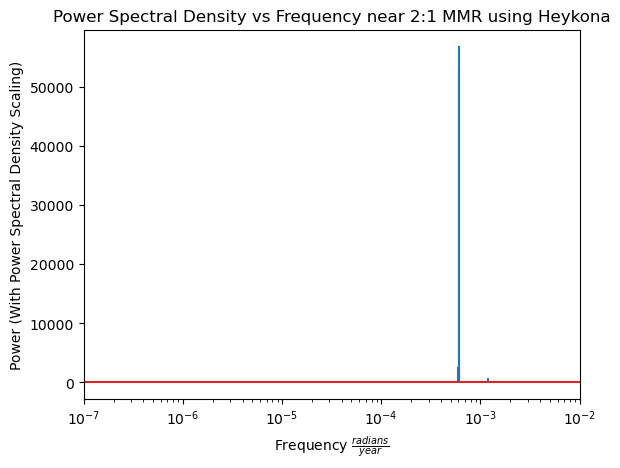

In [9]:
sim = rebound.Simulation()
sim.add(m=1, hash = "Sun")
sim.add(m=m_jup,a=5.6,e=0.06,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim.add(m=1e-10,a=8.9,e=0.03,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

alpha = 5.6/8.9

sim.move_to_com()

times = np.linspace(0,1e7,int(5e3))*2*np.pi
long_peri_sat = np.zeros(len(times))
e_sat = np.zeros(len(times))
long_peri_j = np.zeros(len(times))
e_j = np.zeros(len(times))

pvars = Poincare.from_Simulation(sim)

pham = PoincareHamiltonian(pvars)
pham.add_secular_terms(indexIn=1, indexOut=2, max_order=2)
pham.add_MMR_terms(p=2,q=1,indexIn=1, indexOut=2, max_order=2)
pham.add_MMR_terms(p=3,q=1, indexIn=1, indexOut=2, max_order=2)
pham.add_MMR_terms(p=3,q=2, indexIn=1, indexOut=2, max_order=2)

times, pomega_sat, e_sat = hk_integrate(pham, 1e7, 1e5)

f_hy,pxx_hy = pomega_ft(times, pomega_sat, e_sat)

plt.stem(f_hy*2*np.pi,pxx_hy,markerfmt = "none",label = 'Frequencies found through simulation')
plt.xscale('log')
plt.ylabel('Power (With Power Spectral Density Scaling)')
plt.xlabel(r"Frequency $\frac{radians}{year}$")
plt.xlim(1e-7,1e-2)
plt.title(r'Power Spectral Density vs Frequency near 2:1 MMR using Heykona')

['Lambda1', 'Lambda2', 'eta1', 'eta2', 'kappa1', 'kappa2', 'lambda1', 'lambda2']
*** Differentiating  ***
-8.880166632936593e-05
*** Starting Simulation ***


100%|██████████████████████████████████████████████████████████████████████████████████████| 100000/100000 [00:18<00:00, 5480.89it/s]


-8.880166632936231e-05
Energy Percent Change: 4.074838795534805e-12 %
*** Simulation Complete ***
Time elapsed  = 15.301515783000468 seconds


Text(0.5, 1.0, 'Power Spectral Density vs Frequency near 2:1 MMR using Heykona')

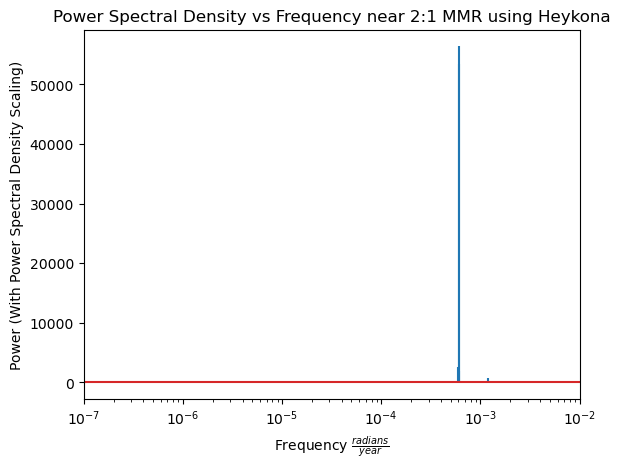

In [12]:
sim = rebound.Simulation()
sim.add(m=1, hash = "Sun")
sim.add(m=m_jup,a=5.6,e=0.06,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim.add(m=1e-10,a=8.9,e=0.03,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

alpha = 5.6/8.9

sim.move_to_com()

times = np.linspace(0,1e7,int(5e3))*2*np.pi
long_peri_sat = np.zeros(len(times))
e_sat = np.zeros(len(times))
long_peri_j = np.zeros(len(times))
e_j = np.zeros(len(times))

pvars = Poincare.from_Simulation(sim)

pham = PoincareHamiltonian(pvars)
pham.add_secular_terms(indexIn=1, indexOut=2, max_order=2)
pham.add_MMR_terms(p=2,q=1,indexIn=1, indexOut=2, max_order=2)
pham.add_MMR_terms(p=3,q=1, indexIn=1, indexOut=2, max_order=2)
pham.add_MMR_terms(p=3,q=2, indexIn=1, indexOut=2, max_order=2)

times, pomega_sat, e_sat = hk_integrate(pham, 1e7, 1e5)

f_hy,pxx_hy = pomega_ft(times, pomega_sat, e_sat)

plt.stem(f_hy*2*np.pi,pxx_hy,markerfmt = "none",label = 'Frequencies found through simulation')
plt.xscale('log')
plt.ylabel('Power (With Power Spectral Density Scaling)')
plt.xlabel(r"Frequency $\frac{radians}{year}$")
plt.xlim(1e-7,1e-2)
plt.title(r'Power Spectral Density vs Frequency near 2:1 MMR using Heykona')

['Lambda1', 'Lambda2', 'eta1', 'eta2', 'kappa1', 'kappa2', 'lambda1', 'lambda2']
*** Differentiating  ***
-0.00010485407464575957
*** Starting Simulation ***


100%|███████████████████████████████████████████████████████████████████████████████████████| 100000/100000 [02:51<00:00, 583.98it/s]


-0.00010485407484549168
Energy Percent Change: 1.9048579458008172e-07 %
*** Simulation Complete ***
Time elapsed  = 156.5530071170033 seconds


Text(0.5, 1.0, 'Power Spectral Density vs Frequency near 2:1 MMR using Heykona')

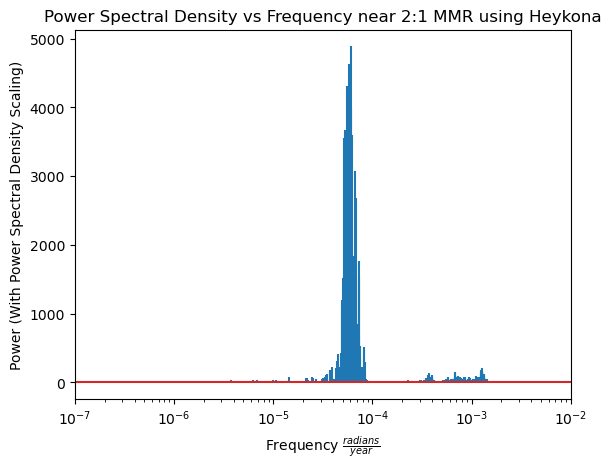

In [16]:
sim = rebound.Simulation()
sim.add(m=1, hash = "Sun")
sim.add(m=m_jup,a=5.6,e=0.12,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim.add(m=m_sat,a=8.9,e=0.06,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

alpha = 5.6/8.9

sim.move_to_com()

times = np.linspace(0,1e7,int(5e3))*2*np.pi
long_peri_sat = np.zeros(len(times))
e_sat = np.zeros(len(times))
long_peri_j = np.zeros(len(times))
e_j = np.zeros(len(times))

pvars = Poincare.from_Simulation(sim)

pham = PoincareHamiltonian(pvars)
pham.add_secular_terms(indexIn=1, indexOut=2, max_order=4)
pham.add_MMR_terms(p=2,q=1,indexIn=1, indexOut=2, max_order=4)
pham.add_MMR_terms(p=9,q=4,indexIn=1, indexOut=2, max_order=5)
pham.add_MMR_terms(p=7,q=3,indexIn=1, indexOut=2, max_order=4)
pham.add_MMR_terms(p=3,q=1, indexIn=1, indexOut=2, max_order=2)
pham.add_MMR_terms(p=13,q=6, indexIn=1, indexOut=2, max_order=6)


times, pomega_sat, e_sat = hk_integrate(pham,1e7,1e5)

f_hy,pxx_hy = pomega_ft(times, pomega_sat, e_sat)

plt.stem(f_hy*2*np.pi,pxx_hy,markerfmt = "none",label = 'Frequencies found through simulation')
plt.xscale('log')
plt.ylabel('Power (With Power Spectral Density Scaling)')
plt.xlabel(r"Frequency $\frac{radians}{year}$")
plt.xlim(1e-7,1e-2)
plt.title(r'Power Spectral Density vs Frequency near 2:1 MMR using Heykona')

['Lambda1', 'Lambda2', 'eta1', 'eta2', 'kappa1', 'kappa2', 'lambda1', 'lambda2']
*** Differentiating  ***
-0.00010485407464575957
*** Starting Simulation ***


100%|███████████████████████████████████████████████████████████████████████████████████████| 100000/100000 [09:06<00:00, 183.06it/s]


-0.00010485407463833628
Energy Percent Change: 7.079637443369156e-09 %
*** Simulation Complete ***
Time elapsed  = 499.278642477002 seconds


Text(0.5, 1.0, 'Power Spectral Density vs Frequency near 2:1 MMR using Heykona')

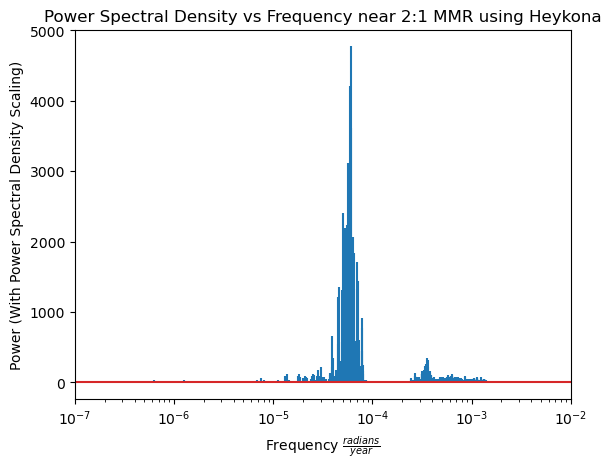

In [18]:
sim = rebound.Simulation()
sim.add(m=1, hash = "Sun")
sim.add(m=m_jup,a=5.6,e=0.12,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim.add(m=m_sat,a=8.9,e=0.06,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

alpha = 5.6/8.9

sim.move_to_com()

times = np.linspace(0,1e7,int(5e3))*2*np.pi
long_peri_sat = np.zeros(len(times))
e_sat = np.zeros(len(times))
long_peri_j = np.zeros(len(times))
e_j = np.zeros(len(times))

pvars = Poincare.from_Simulation(sim)

pham = PoincareHamiltonian(pvars)
pham.add_secular_terms(indexIn=1, indexOut=2, max_order=4)
pham.add_MMR_terms(p=2,q=1,indexIn=1, indexOut=2, max_order=4)
pham.add_MMR_terms(p=9,q=4,indexIn=1, indexOut=2, max_order=5)
pham.add_MMR_terms(p=7,q=3,indexIn=1, indexOut=2, max_order=4)
pham.add_MMR_terms(p=3,q=1, indexIn=1, indexOut=2, max_order=2)
pham.add_MMR_terms(p=13,q=6, indexIn=1, indexOut=2, max_order=6)


times, pomega_sat, e_sat = hk_integrate(pham,1e7,1e5)

f_hy,pxx_hy = pomega_ft(times, pomega_sat, e_sat)

plt.stem(f_hy*2*np.pi,pxx_hy,markerfmt = "none",label = 'Frequencies found through simulation')
plt.xscale('log')
plt.ylabel('Power (With Power Spectral Density Scaling)')
plt.xlabel(r"Frequency $\frac{radians}{year}$")
plt.xlim(1e-7,1e-2)
plt.title(r'Power Spectral Density vs Frequency near 2:1 MMR using Heykona')

['Lambda1', 'Lambda2', 'eta1', 'eta2', 'kappa1', 'kappa2', 'lambda1', 'lambda2']
*** Differentiating  ***
-0.00010485410747347558
*** Starting Simulation ***


100%|███████████████████████████████████████████████████████████████████████████████████████| 100000/100000 [05:27<00:00, 304.89it/s]


-0.00010485410749701842
Energy Percent Change: 2.2452949988398137e-08 %
*** Simulation Complete ***
Time elapsed  = 298.6141450990035 seconds


Text(0.5, 1.0, 'Power Spectral Density vs Frequency near 2:1 MMR using Heykona')

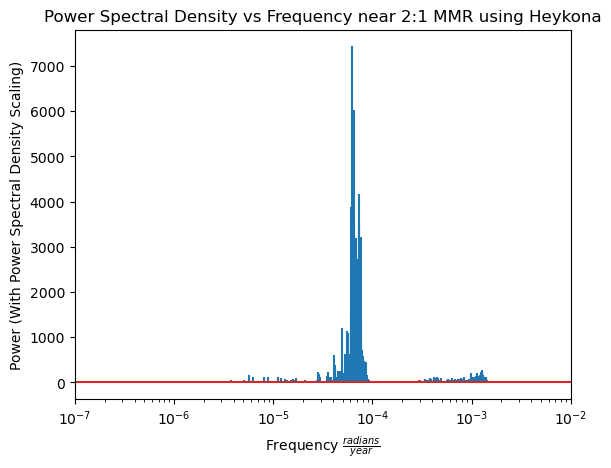

In [19]:
sim = rebound.Simulation()
sim.add(m=1, hash = "Sun")
sim.add(m=m_jup,a=5.6,e=0.12,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim.add(m=m_sat,a=8.9,e=0.06,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

alpha = 5.6/8.9

sim.move_to_com()

times = np.linspace(0,1e7,int(5e3))*2*np.pi
long_peri_sat = np.zeros(len(times))
e_sat = np.zeros(len(times))
long_peri_j = np.zeros(len(times))
e_j = np.zeros(len(times))

pvars = Poincare.from_Simulation(sim)

pham = PoincareHamiltonian(pvars)
pham.add_secular_terms(indexIn=1, indexOut=2, max_order=4)
pham.add_MMR_terms(p=2,q=1,indexIn=1, indexOut=2, max_order=4)
pham.add_MMR_terms(p=7,q=3,indexIn=1, indexOut=2, max_order=4)
pham.add_MMR_terms(p=3,q=1, indexIn=1, indexOut=2, max_order=2)

times, pomega_sat, e_sat = hk_integrate(pham,1e7,1e5)

f_hy,pxx_hy = pomega_ft(times, pomega_sat, e_sat)

plt.stem(f_hy*2*np.pi,pxx_hy,markerfmt = "none",label = 'Frequencies found through simulation')
plt.xscale('log')
plt.ylabel('Power (With Power Spectral Density Scaling)')
plt.xlabel(r"Frequency $\frac{radians}{year}$")
plt.xlim(1e-7,1e-2)
plt.title(r'Power Spectral Density vs Frequency near 2:1 MMR using Heykona')

['Lambda1', 'Lambda2', 'eta1', 'eta2', 'kappa1', 'kappa2', 'lambda1', 'lambda2']
*** Differentiating  ***
-0.0001048546038162311
*** Starting Simulation ***


100%|███████████████████████████████████████████████████████████████████████████████████████| 100000/100000 [05:00<00:00, 332.31it/s]


-0.0001048546038146581
Energy Percent Change: 1.5001736806714666e-09 %
*** Simulation Complete ***
Time elapsed  = 277.420858417001 seconds


Text(0.5, 1.0, 'Power Spectral Density vs Frequency near 2:1 MMR using Heykona')

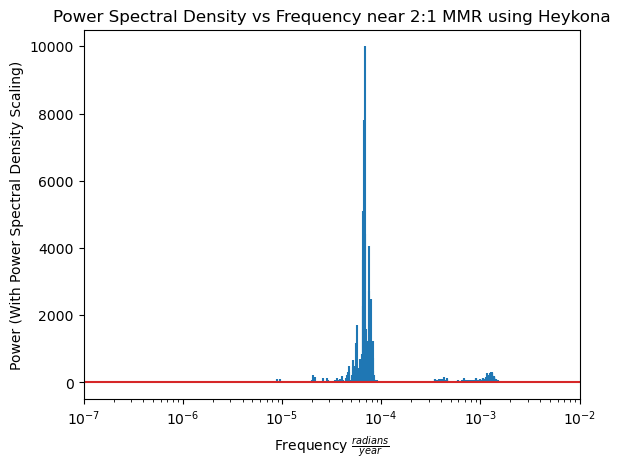

In [21]:
sim = rebound.Simulation()
sim.add(m=1, hash = "Sun")
sim.add(m=m_jup,a=5.6,e=0.12,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim.add(m=m_sat,a=8.9,e=0.06,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

alpha = 5.6/8.9

sim.move_to_com()

times = np.linspace(0,1e7,int(5e3))*2*np.pi
long_peri_sat = np.zeros(len(times))
e_sat = np.zeros(len(times))
long_peri_j = np.zeros(len(times))
e_j = np.zeros(len(times))

pvars = Poincare.from_Simulation(sim)

pham = PoincareHamiltonian(pvars)
pham.add_secular_terms(indexIn=1, indexOut=2, max_order=4)
pham.add_MMR_terms(p=2,q=1,indexIn=1, indexOut=2, max_order=4)
pham.add_MMR_terms(p=7,q=3,indexIn=1, indexOut=2, max_order=4)

times, pomega_sat, e_sat = hk_integrate(pham,1e7,1e5)

f_hy,pxx_hy = pomega_ft(times, pomega_sat, e_sat)

plt.stem(f_hy*2*np.pi,pxx_hy,markerfmt = "none",label = 'Frequencies found through simulation')
plt.xscale('log')
plt.ylabel('Power (With Power Spectral Density Scaling)')
plt.xlabel(r"Frequency $\frac{radians}{year}$")
plt.xlim(1e-7,1e-2)
plt.title(r'Power Spectral Density vs Frequency near 2:1 MMR using Heykona')

['Lambda1', 'Lambda2', 'eta1', 'eta2', 'kappa1', 'kappa2', 'lambda1', 'lambda2']
*** Differentiating  ***
-0.00010485357006784253
*** Starting Simulation ***


100%|██████████████████████████████████████████████████████████████████████████████████████| 100000/100000 [00:42<00:00, 2378.89it/s]


-0.00010485357088973072
Energy Percent Change: 7.838437777067062e-07 %
*** Simulation Complete ***
Time elapsed  = 39.10043018699798 seconds


Text(0.5, 1.0, 'Power Spectral Density vs Frequency near 2:1 MMR using Heykona')

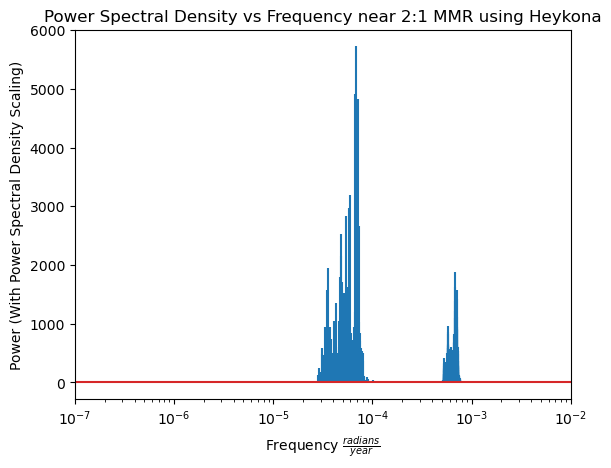

In [22]:
sim = rebound.Simulation()
sim.add(m=1, hash = "Sun")
sim.add(m=m_jup,a=5.6,e=0.12,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim.add(m=m_sat,a=8.9,e=0.06,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

alpha = 5.6/8.9

sim.move_to_com()

times = np.linspace(0,1e7,int(5e3))*2*np.pi
long_peri_sat = np.zeros(len(times))
e_sat = np.zeros(len(times))
long_peri_j = np.zeros(len(times))
e_j = np.zeros(len(times))

pvars = Poincare.from_Simulation(sim)

pham = PoincareHamiltonian(pvars)
pham.add_secular_terms(indexIn=1, indexOut=2, max_order=2)
pham.add_MMR_terms(p=2,q=1,indexIn=1, indexOut=2, max_order=1)
pham.add_MMR_terms(p=7,q=3,indexIn=1, indexOut=2, max_order=3)

times, pomega_sat, e_sat = hk_integrate(pham,1e7,1e5)

f_hy,pxx_hy = pomega_ft(times, pomega_sat, e_sat)

plt.stem(f_hy*2*np.pi,pxx_hy,markerfmt = "none",label = 'Frequencies found through simulation')
plt.xscale('log')
plt.ylabel('Power (With Power Spectral Density Scaling)')
plt.xlabel(r"Frequency $\frac{radians}{year}$")
plt.xlim(1e-7,1e-2)
plt.title(r'Power Spectral Density vs Frequency near 2:1 MMR using Heykona')

['Lambda1', 'Lambda2', 'eta1', 'eta2', 'kappa1', 'kappa2', 'lambda1', 'lambda2']
*** Differentiating  ***
-0.00010485357006784253
*** Starting Simulation ***


100%|███████████████████████████████████████████████████████████████████████████████████████| 100000/100000 [07:02<00:00, 236.83it/s]


-0.00010485357020633806
Energy Percent Change: 1.3208470120546723e-07 %
*** Simulation Complete ***
Time elapsed  = 386.99451952800155 seconds


Text(0.5, 1.0, 'Power Spectral Density vs Frequency near 2:1 MMR using Heykona')

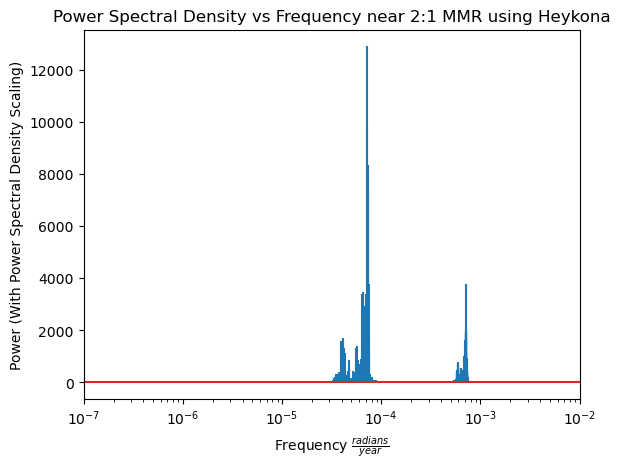

In [26]:
sim = rebound.Simulation()
sim.add(m=1, hash = "Sun")
sim.add(m=m_jup,a=5.6,e=0.12,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim.add(m=m_sat,a=8.9,e=0.06,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

alpha = 5.6/8.9

sim.move_to_com()

times = np.linspace(0,1e7,int(5e3))*2*np.pi
long_peri_sat = np.zeros(len(times))
e_sat = np.zeros(len(times))
long_peri_j = np.zeros(len(times))
e_j = np.zeros(len(times))

pvars = Poincare.from_Simulation(sim)

pham = PoincareHamiltonian(pvars)
pham.add_secular_terms(indexIn=1, indexOut=2, max_order=2)
pham.add_MMR_terms(p=2,q=1,indexIn=1, indexOut=2, max_order=1)
pham.add_MMR_terms(p=7,q=3,indexIn=1, indexOut=2, max_order=3)

times, pomega_sat, e_sat = hk_integrate(pham,1e7,1e5)

f_hy,pxx_hy = pomega_ft(times, pomega_sat, e_sat)

plt.stem(f_hy*2*np.pi,pxx_hy,markerfmt = "none",label = 'Frequencies found through simulation')
plt.xscale('log')
plt.ylabel('Power (With Power Spectral Density Scaling)')
plt.xlabel(r"Frequency $\frac{radians}{year}$")
plt.xlim(1e-7,1e-2)
plt.title(r'Power Spectral Density vs Frequency near 2:1 MMR using Heykona')

['Lambda1', 'Lambda2', 'eta1', 'eta2', 'kappa1', 'kappa2', 'lambda1', 'lambda2']
*** Differentiating  ***
-8.880166633004715e-05
*** Starting Simulation ***


100%|█████████████████████████████████████████████████████████████████████████| 100000/100000 [00:40<00:00, 2468.94it/s]


-8.880166633007177e-05
Energy Percent Change: 2.773027000535559e-11 %
*** Simulation Complete ***
Time elapsed  = 37.572951055000004 seconds


Text(0.5, 1.0, 'Power Spectral Density vs Frequency near 2:1 MMR using Heykona')

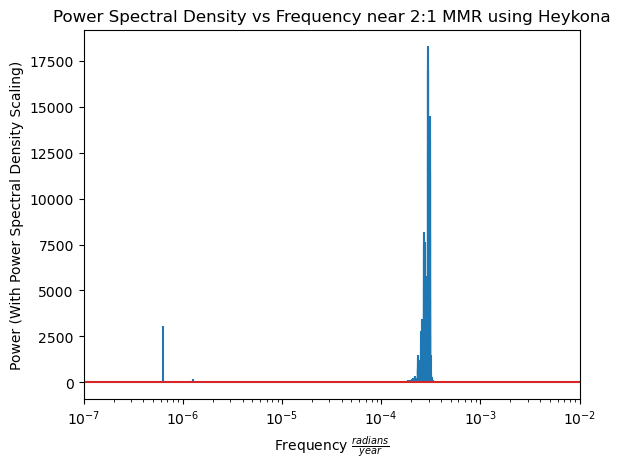

In [6]:
sim = rebound.Simulation()
sim.add(m=1, hash = "Sun")
sim.add(m=m_jup,a=5.6,e=0.12,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim.add(m=1e-10,a=8.9,e=0.06,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

alpha = 5.6/8.9

sim.move_to_com()

times = np.linspace(0,1e7,int(5e3))*2*np.pi
long_peri_sat = np.zeros(len(times))
e_sat = np.zeros(len(times))
long_peri_j = np.zeros(len(times))
e_j = np.zeros(len(times))

pvars = Poincare.from_Simulation(sim)

pham = PoincareHamiltonian(pvars)
pham.add_secular_terms(indexIn=1, indexOut=2, max_order=2)
pham.add_MMR_terms(p=2,q=1,indexIn=1, indexOut=2, max_order=1)
pham.add_MMR_terms(p=7,q=3,indexIn=1, indexOut=2, max_order=3)

times, pomega_sat, e_sat = hk_integrate(pham,1e7,1e5)

f_hy,pxx_hy = pomega_ft(times, pomega_sat, e_sat)

plt.stem(f_hy*2*np.pi,pxx_hy,markerfmt = "none",label = 'Frequencies found through simulation')
plt.xscale('log')
plt.ylabel('Power (With Power Spectral Density Scaling)')
plt.xlabel(r"Frequency $\frac{radians}{year}$")
plt.xlim(1e-7,1e-2)
plt.title(r'Power Spectral Density vs Frequency near 2:1 MMR using Heykona')

['Lambda1', 'Lambda2', 'eta1', 'eta2', 'kappa1', 'kappa2', 'lambda1', 'lambda2']
*** Differentiating  ***
-8.880166633007245e-05
*** Starting Simulation ***


100%|█████████████████████████████████████████████████████████████████████████| 100000/100000 [01:10<00:00, 1421.84it/s]


-8.880166633002748e-05
Energy Percent Change: 5.063788435759144e-11 %
*** Simulation Complete ***
Time elapsed  = 64.46077316600002 seconds


Text(0.5, 1.0, 'Power Spectral Density vs Frequency near 2:1 MMR using Heykona')

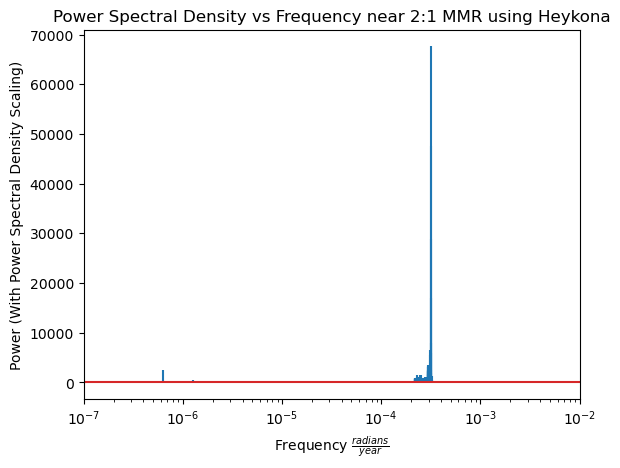

In [9]:
sim = rebound.Simulation()
sim.add(m=1, hash = "Sun")
sim.add(m=m_jup,a=5.6,e=0.12,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim.add(m=1e-10,a=8.9,e=0.06,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

alpha = 5.6/8.9

sim.move_to_com()

times = np.linspace(0,1e7,int(5e3))*2*np.pi
long_peri_sat = np.zeros(len(times))
e_sat = np.zeros(len(times))
long_peri_j = np.zeros(len(times))
e_j = np.zeros(len(times))

pvars = Poincare.from_Simulation(sim)

pham = PoincareHamiltonian(pvars)
pham.add_secular_terms(indexIn=1, indexOut=2, max_order=2)
pham.add_MMR_terms(p=2,q=1,indexIn=1, indexOut=2, max_order=1)

times, pomega_sat, e_sat = hk_integrate(pham,1e7,1e5)

f_hy,pxx_hy = pomega_ft(times, pomega_sat, e_sat)

plt.stem(f_hy*2*np.pi,pxx_hy,markerfmt = "none",label = 'Frequencies found through simulation')
plt.xscale('log')
plt.ylabel('Power (With Power Spectral Density Scaling)')
plt.xlabel(r"Frequency $\frac{radians}{year}$")
plt.xlim(1e-7,1e-2)
plt.title(r'Power Spectral Density vs Frequency near 2:1 MMR using Heykona')

Initial Energy: -8.88016663300471e-05


100%|███████████████████████████████████████████████████████████████████████████| 100000/100000 [40:13<00:00, 41.44it/s]


Final Energy: -8.88016663355548e-05
Energy Percent Change: 6.202255662832418e-09 %


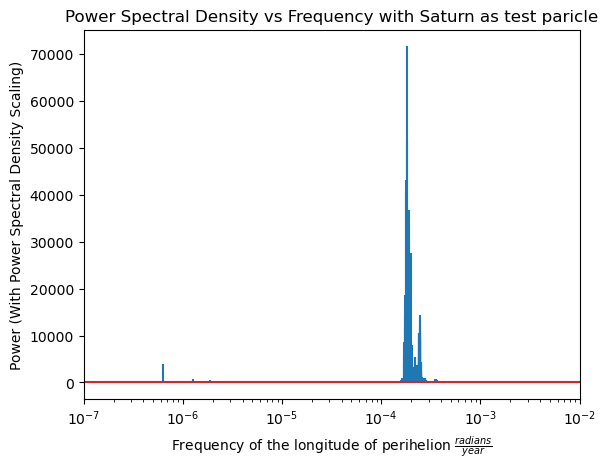

In [10]:
sim = rebound.Simulation()
sim.add(m=1, hash = "Sun")
sim.add(m=m_jup,a=5.6,e=0.12,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim.add(m=1e-10,a=8.9,e=0.06,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

sim.move_to_com()

times = np.linspace(0,1e7,int(1e5))*2*np.pi
long_peri_sat = np.zeros(len(times))
e_sat = np.zeros(len(times))
long_peri_j = np.zeros(len(times))
e_j = np.zeros(len(times))

pvars = Poincare.from_Simulation(sim)

pham = PoincareHamiltonian(pvars)
pham.add_secular_terms(indexIn=1, indexOut=2, max_order=2)
pham.add_MMR_terms(p=2,q=1,indexIn=1, indexOut=2, max_order=1)
pham.add_MMR_terms(p=7,q=3,indexIn=1, indexOut=2, max_order=3)

e_i = pham.calculate_energy()
print('Initial Energy: '+ str(e_i))

for i in tqdm(range(len(times))):
    pham.integrate(times[i])
    long_peri_sat[i] = pham.state.particles[2].pomega
    e_sat[i] = pham.state.particles[2].e

e_f = pham.calculate_energy()
print('Final Energy: '+ str(e_f))
e_per = (np.abs(e_i - e_f)/np.abs(e_i))*100 
print(f'Energy Percent Change: {e_per} %')
f,pxx = pomega_ft(times, long_peri_sat, e_sat)
plt.stem(f*2*np.pi,pxx,markerfmt = "none",label = 'Frequencies found through simulation')
plt.xscale('log')
plt.ylabel('Power (With Power Spectral Density Scaling)')
plt.xlabel(r"Frequency of the longitude of perihelion $\frac{radians}{year}$")
plt.xlim(1e-7,1e-2)
plt.title(r'Power Spectral Density vs Frequency with Saturn as test paricle')
plt.show()

Initial Energy: -8.880166633579643e-05
Initital Angular Momentum: <rebound.vectors.Vec3d object at 0x734d9183dbe0, [0.0, 0.0, 0.0023354343525747484]>


100%|██████████████████████████████████████████████████████████████████████████| 100000/100000 [04:55<00:00, 338.23it/s]


Final Energy: " -8.88016663355548e-05
Energy Percent Change: 2.72098505169772e-10 %


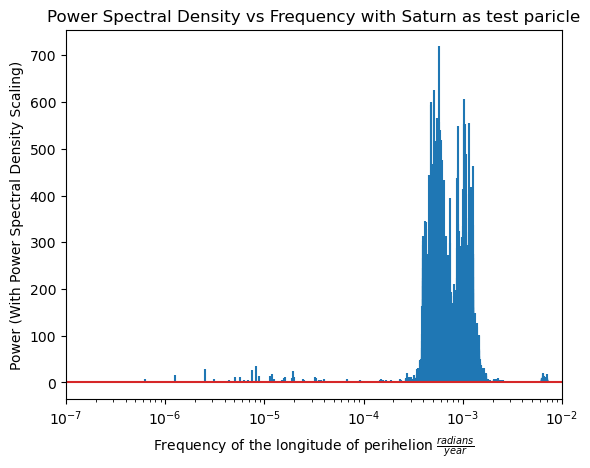

In [11]:
sim = rebound.Simulation()
sim.integrator = "whfast"
sim.dt = 1e-1
sim.add(m=1, hash = "Sun")
sim.add(m=m_jup,a=5.6,e=0.12,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim.add(m=1e-10,a=8.9,e=0.06,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

sim.move_to_com()

times = np.linspace(0,1e7,int(1e5))*2*np.pi
long_peri_sat = np.zeros(len(times))
e_sat = np.zeros(len(times))
long_peri_j = np.zeros(len(times))
e_j = np.zeros(len(times))
H_energy = np.zeros(len(times))

#sim.init_megno()

e_i = sim.energy()
print('Initial Energy: ' + str(e_i))
print('Initital Angular Momentum: ' + str(sim.angular_momentum()))

for i in tqdm(range(len(times))):
    sim.integrate(times[i])
    long_peri_sat[i] = sim.particles[2].pomega
    e_sat[i] = sim.particles[2].e
    e_j[i] = sim.particles[1].e
    
e_f = pham.calculate_energy()
print('Final Energy: " '+ str(e_f))
e_per = (np.abs(e_i - e_f)/np.abs(e_i))*100 
print(f'Energy Percent Change: {e_per} %')

f,pxx = pomega_ft(times, long_peri_sat, e_sat)
plt.stem(f*2*np.pi,pxx,markerfmt = "none",label = 'Frequencies found through simulation')
plt.xscale('log')
plt.ylabel('Power (With Power Spectral Density Scaling)')
plt.xlabel(r"Frequency of the longitude of perihelion $\frac{radians}{year}$")
plt.xlim(1e-7,1e-2)
plt.title(r'Power Spectral Density vs Frequency with Saturn as test paricle')
plt.show()

Initial Energy: -8.880166633579643e-05
Initital Angular Momentum: <rebound.vectors.Vec3d object at 0x734d83d974d0, [0.0, 0.0, 0.0023354343525747484]>


100%|██████████████████████████████████████████████████████████████████████████| 100000/100000 [02:58<00:00, 559.48it/s]


Final Energy: " -8.88016663355548e-05
Energy Percent Change: 2.72098505169772e-10 %


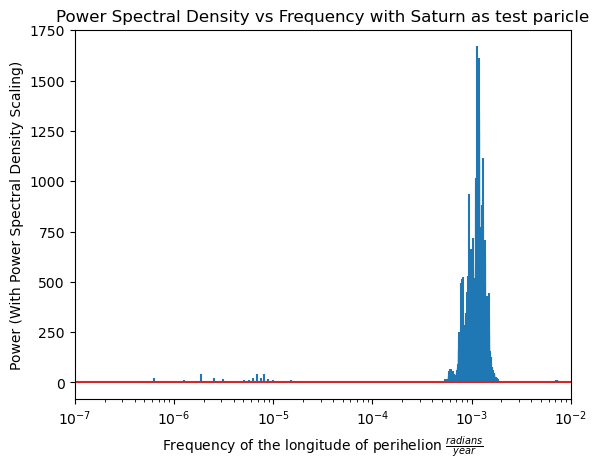

In [12]:
sim = rebound.Simulation()
sim.integrator = "ias15"
#sim.dt = 1e-1
sim.add(m=1, hash = "Sun")
sim.add(m=m_jup,a=5.6,e=0.12,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim.add(m=1e-10,a=8.9,e=0.06,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

sim.move_to_com()

times = np.linspace(0,1e7,int(1e5))*2*np.pi
long_peri_sat = np.zeros(len(times))
e_sat = np.zeros(len(times))
long_peri_j = np.zeros(len(times))
e_j = np.zeros(len(times))
H_energy = np.zeros(len(times))

#sim.init_megno()

e_i = sim.energy()
print('Initial Energy: ' + str(e_i))
print('Initital Angular Momentum: ' + str(sim.angular_momentum()))

for i in tqdm(range(len(times))):
    sim.integrate(times[i])
    long_peri_sat[i] = sim.particles[2].pomega
    e_sat[i] = sim.particles[2].e
    e_j[i] = sim.particles[1].e
    
e_f = pham.calculate_energy()
print('Final Energy: " '+ str(e_f))
e_per = (np.abs(e_i - e_f)/np.abs(e_i))*100 
print(f'Energy Percent Change: {e_per} %')

f,pxx = pomega_ft(times, long_peri_sat, e_sat)
plt.stem(f*2*np.pi,pxx,markerfmt = "none",label = 'Frequencies found through simulation')
plt.xscale('log')
plt.ylabel('Power (With Power Spectral Density Scaling)')
plt.xlabel(r"Frequency of the longitude of perihelion $\frac{radians}{year}$")
plt.xlim(1e-7,1e-2)
plt.title(r'Power Spectral Density vs Frequency with Saturn as test paricle')
plt.show()

Initial Energy: -8.880166633556529e-05
Initital Angular Momentum: <rebound.vectors.Vec3d object at 0x734d5e988550, [0.0, 0.0, 0.002340641569444528]>


100%|██████████████████████████████████████████████████████████████████████████| 100000/100000 [05:17<00:00, 315.29it/s]


Final Energy: " -8.88016663355548e-05
Energy Percent Change: 1.181245403566951e-11 %


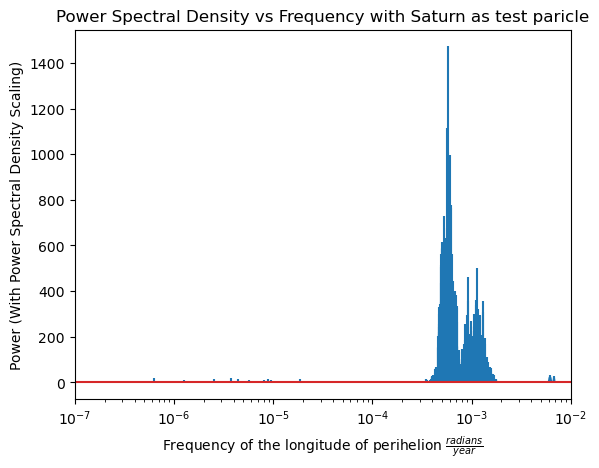

In [13]:
sim = rebound.Simulation()
sim.integrator = "whfast"
sim.dt = 1e-1
sim.add(m=1, hash = "Sun")
sim.add(m=m_jup,a=5.6,e=0.1,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim.add(m=1e-10,a=8.9,e=0.08,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

sim.move_to_com()

times = np.linspace(0,1e7,int(1e5))*2*np.pi
long_peri_sat = np.zeros(len(times))
e_sat = np.zeros(len(times))
long_peri_j = np.zeros(len(times))
e_j = np.zeros(len(times))
H_energy = np.zeros(len(times))

#sim.init_megno()

e_i = sim.energy()
print('Initial Energy: ' + str(e_i))
print('Initital Angular Momentum: ' + str(sim.angular_momentum()))

for i in tqdm(range(len(times))):
    sim.integrate(times[i])
    long_peri_sat[i] = sim.particles[2].pomega
    e_sat[i] = sim.particles[2].e
    e_j[i] = sim.particles[1].e
    
e_f = pham.calculate_energy()
print('Final Energy: " '+ str(e_f))
e_per = (np.abs(e_i - e_f)/np.abs(e_i))*100 
print(f'Energy Percent Change: {e_per} %')

f,pxx = pomega_ft(times, long_peri_sat, e_sat)
plt.stem(f*2*np.pi,pxx,markerfmt = "none",label = 'Frequencies found through simulation')
plt.xscale('log')
plt.ylabel('Power (With Power Spectral Density Scaling)')
plt.xlabel(r"Frequency of the longitude of perihelion $\frac{radians}{year}$")
plt.xlim(1e-7,1e-2)
plt.title(r'Power Spectral Density vs Frequency with Saturn as test paricle')
plt.show()

Initial Energy: -8.880166632947636e-05


100%|█████████████████████████████████████████████████████████████████████████| 100000/100000 [01:26<00:00, 1159.02it/s]


Final Energy: -8.880166632940506e-05
Energy Percent Change: 8.029111199731068e-11 %


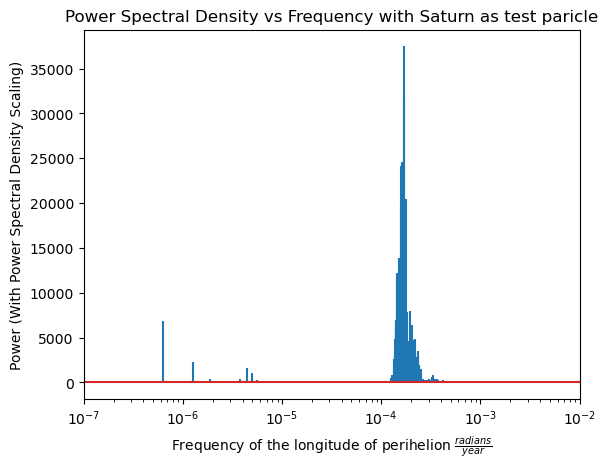

In [14]:
sim = rebound.Simulation()
sim.add(m=1, hash = "Sun")
sim.add(m=m_jup,a=5.6,e=0.1,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim.add(m=1e-10,a=8.9,e=0.08,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

sim.move_to_com()

times = np.linspace(0,1e7,int(1e5))*2*np.pi
long_peri_sat = np.zeros(len(times))
e_sat = np.zeros(len(times))
long_peri_j = np.zeros(len(times))
e_j = np.zeros(len(times))

pvars = Poincare.from_Simulation(sim)

pham = PoincareHamiltonian(pvars)
pham.add_secular_terms(indexIn=1, indexOut=2,l_max = 0, max_order=2)
pham.add_MMR_terms(p=2,q=1,indexIn=1, indexOut=2,l_max = 0, max_order=1)

e_i = pham.calculate_energy()
print('Initial Energy: '+ str(e_i))

for i in tqdm(range(len(times))):
    pham.integrate(times[i])
    long_peri_sat[i] = pham.state.particles[2].pomega
    e_sat[i] = pham.state.particles[2].e

e_f = pham.calculate_energy()
print('Final Energy: '+ str(e_f))
e_per = (np.abs(e_i - e_f)/np.abs(e_i))*100 
print(f'Energy Percent Change: {e_per} %')
f,pxx = pomega_ft(times, long_peri_sat, e_sat)
plt.stem(f*2*np.pi,pxx,markerfmt = "none",label = 'Frequencies found through simulation')
plt.xscale('log')
plt.ylabel('Power (With Power Spectral Density Scaling)')
plt.xlabel(r"Frequency of the longitude of perihelion $\frac{radians}{year}$")
plt.xlim(1e-7,1e-2)
plt.title(r'Power Spectral Density vs Frequency with Saturn as test paricle')
plt.show()

['Lambda1', 'Lambda2', 'eta1', 'eta2', 'kappa1', 'kappa2', 'lambda1', 'lambda2']
*** Differentiating  ***
-8.880166632947642e-05
*** Starting Simulation ***


100%|██████████████████████████████████████████████████████████████████████████████████████| 100000/100000 [01:07<00:00, 1485.86it/s]


-8.880166632942513e-05
Energy Percent Change: 5.77650368579777e-11 %
*** Simulation Complete ***
Time elapsed  = 60.12628156299979 seconds


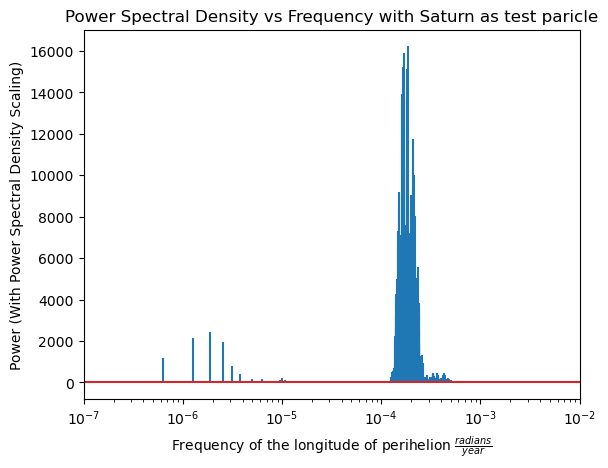

In [6]:
#max dt = 1.0
sim = rebound.Simulation()
sim.add(m=1, hash = "Sun")
sim.add(m=m_jup,a=5.6,e=0.1,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim.add(m=1e-10,a=8.9,e=0.08,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

sim.move_to_com()

pvars = Poincare.from_Simulation(sim)

pham = PoincareHamiltonian(pvars)
pham.add_secular_terms(indexIn=1, indexOut=2, max_order=2)
pham.add_MMR_terms(p=2,q=1,indexIn=1, indexOut=2, max_order=1)

times, pomega_sat, e_sat = hk_integrate(pham,1e7,1e5)

f,pxx = pomega_ft(times, pomega_sat, e_sat)
plt.stem(f*2*np.pi,pxx,markerfmt = "none",label = 'Frequencies found through simulation')
plt.xscale('log')
plt.ylabel('Power (With Power Spectral Density Scaling)')
plt.xlabel(r"Frequency of the longitude of perihelion $\frac{radians}{year}$")
plt.xlim(1e-7,1e-2)
plt.title(r'Power Spectral Density vs Frequency with Saturn as test paricle')
plt.show()

['Lambda1', 'Lambda2', 'eta1', 'eta2', 'kappa1', 'kappa2', 'lambda1', 'lambda2']
*** Differentiating  ***
-8.880166632947642e-05
*** Starting Simulation ***


100%|███████████████████████████████████████████████████████████████████████████████████████| 100000/100000 [10:42<00:00, 155.54it/s]


-8.880166632983837e-05
Energy Percent Change: 4.0759071053263157e-10 %
*** Simulation Complete ***
Time elapsed  = 587.0900869859979 seconds


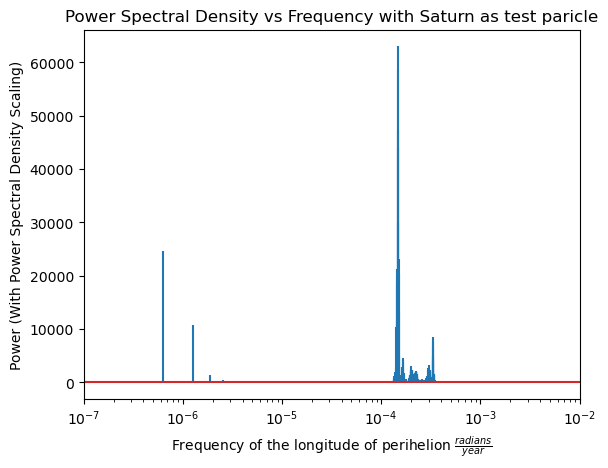

In [16]:
#max dt = 0.1
sim = rebound.Simulation()
sim.add(m=1, hash = "Sun")
sim.add(m=m_jup,a=5.6,e=0.1,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim.add(m=1e-10,a=8.9,e=0.08,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

sim.move_to_com()

pvars = Poincare.from_Simulation(sim)

pham = PoincareHamiltonian(pvars)
pham.add_secular_terms(indexIn=1, indexOut=2, max_order=2)
pham.add_MMR_terms(p=2,q=1,indexIn=1, indexOut=2, max_order=1)

times, pomega_sat, e_sat = hk_integrate(pham,1e7,1e5)

f,pxx = pomega_ft(times, pomega_sat, e_sat)
plt.stem(f*2*np.pi,pxx,markerfmt = "none",label = 'Frequencies found through simulation')
plt.xscale('log')
plt.ylabel('Power (With Power Spectral Density Scaling)')
plt.xlabel(r"Frequency of the longitude of perihelion $\frac{radians}{year}$")
plt.xlim(1e-7,1e-2)
plt.title(r'Power Spectral Density vs Frequency with Saturn as test paricle')
plt.show()